# Fase 4 · Regresión logística multinomial

**Universidad:** UNIFRANZ — **Materia:** Minería de Datos.

**Integrantes:** Milenka Melody Chuquimia Osco; Edson Teddy Tito Chuquimia; Carlos Daniel Valverde Mendoza; Alvaro Luis Carlos del Carpio Blanco; Marcelo Josue Escobar Chipana.

Clasificación retrospectiva de registros completos. La población corresponde a los estudiantes universitarios representados en el CSV. La etiqueta no es un diagnóstico clínico. No se demuestra causalidad, representatividad institucional ni detección anticipada. El KPI descriptivo es 24,974 % de etiquetas High; no mide calidad predictiva.


## Objetivo, hipótesis, algoritmo y límites

Hipótesis: una frontera multinomial regularizada ofrece una referencia útil e interpretable. Optimiza una pérdida logística conjunta y probabilidades para tres clases. L2 controla magnitudes; C invierte la fuerza de regularización. No exige normalidad de predictores; sí limita la forma de la frontera en el espacio transformado. Supone registros independientes para la interpretación usual; la muestra no acredita generalización externa.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "wrangler/03_PREPARACION_DATOS/artefactos/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "wrangler/04_MODELADO"))
from eduanalytics_modelado import core
from eduanalytics_modelado.academico import texto, metricas, matrices, presentar_modelo, presentar_comparacion
import pandas as pd
from IPython.display import display
entradas = core.verificar_entradas()
print("Python:", core.versiones()["Python"], "scikit-learn:", core.versiones()["scikit-learn"])
print("CSV:", entradas["input"]["path"], "SHA-256:", entradas["input"]["sha256"])
directory = core.experimento_actual()
X, y, trace = core.cargar("train")
Xv, yv, tracev = core.cargar("validation")
print("Entrenamiento", X.shape, "Validación", Xv.shape)
assert X.index.equals(y.index)
assert not {"Student_ID", "_row_id", "Burnout_Risk_Level"} & set(X.columns)

Python: 3.10.6 scikit-learn: 1.7.2
CSV: dataset/ai_student_impact_dataset (1).csv SHA-256: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5
Entrenamiento (35000, 14) Validación (7500, 14)


## Preprocesamiento y configuración inicial

La fábrica "logistica" estandariza ocho numéricas, convierte booleanos a 0/1 y aplica one-hot a cinco categóricas. solver lbfgs, L2, max_iter 5000, tol 1e-4. C: 0.01, 0.1, 1, 10, 100; pesos None/balanced. No se establece multi_class, obsoleto en 1.7.2. Se verifica convergencia y se detiene ante ConvergenceWarning. Cada búsqueda recibe un pipeline nuevo, sin ajustar. Balanced se calcula dentro de cada ajuste, no antes de dividir. No se usa SMOTE, imputación ni recortes. Las desconocidas generan bloques one-hot de ceros.

In [2]:
pipeline = core.crear_pipeline("logistica")
display(pipeline)
display(core.ESPACIOS["logistica"])

,steps,"[('preprocesamiento', ...), ('clasificador', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('columnas', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...), ...]"
,remainder,'drop'
,sparse_threshold,0


{'clasificador__C': [0.01, 0.1, 1, 10, 100],
 'clasificador__class_weight': [None, 'balanced']}

## Búsqueda, resultados y explicación

El código compartido ejecuta o verifica la búsqueda completa, guarda parámetros de todas las configuraciones y evalúa el ganador en entrenamiento y validación. Las tablas y comentarios siguientes proceden de esos cálculos. La ejecución repetida reutiliza recibos válidos, sin ejecutar nuevamente la búsqueda.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clasificador__C,param_clasificador__class_weight,params,split0_test_score,split1_test_score,split2_test_score,...,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,configuration_index
0,0.167637,0.021096,0.028596,0.001191,100.00,NaN,"{""clasificador__C"":100,""clasificador__class_we...",0.541494,0.540948,0.536053,...,0.003304,1,0.541036,0.540416,0.541892,0.538778,0.541318,0.540688,0.001067,8
1,0.162810,0.004916,0.028498,0.001703,10.00,NaN,"{""clasificador__C"":10,""clasificador__class_wei...",0.541494,0.540758,0.536053,...,0.003289,2,0.541036,0.540444,0.541892,0.538778,0.541353,0.540701,0.001070,6
2,0.173473,0.015165,0.033232,0.004679,1.00,NaN,"{""clasificador__C"":1,""clasificador__class_weig...",0.541604,0.540758,0.535749,...,0.003398,3,0.541039,0.540286,0.542066,0.538880,0.541284,0.540711,0.001078,4
3,0.184403,0.017554,0.036095,0.002169,0.10,NaN,"{""clasificador__C"":0.1,""clasificador__class_we...",0.541277,0.540569,0.535790,...,0.003145,4,0.540463,0.540072,0.542089,0.538762,0.541288,0.540535,0.001127,2
4,0.224063,0.045987,0.031932,0.006511,0.01,NaN,"{""clasificador__C"":0.01,""clasificador__class_w...",0.542145,0.540456,0.531450,...,0.003994,5,0.538891,0.539139,0.540484,0.538312,0.538929,0.539151,0.000721,0
5,0.168098,0.015325,0.033255,0.004815,1.00,balanced,"{""clasificador__C"":1,""clasificador__class_weig...",0.513496,0.520233,0.513627,...,0.003254,6,0.518207,0.516527,0.520033,0.516712,0.519587,0.518213,0.001435,5
6,0.159108,0.007130,0.030125,0.003451,100.00,balanced,"{""clasificador__C"":100,""clasificador__class_we...",0.513643,0.520163,0.513482,...,0.003243,7,0.518118,0.516349,0.520148,0.516706,0.519634,0.518191,0.001518,9
7,0.166060,0.015270,0.031719,0.004597,10.00,balanced,"{""clasificador__C"":10,""clasificador__class_wei...",0.513643,0.520086,0.513482,...,0.003218,8,0.518116,0.516360,0.520111,0.516738,0.519634,0.518192,0.001499,7
8,0.194615,0.015489,0.036936,0.005145,0.10,balanced,"{""clasificador__C"":0.1,""clasificador__class_we...",0.513671,0.520573,0.513639,...,0.003157,9,0.517861,0.516082,0.520171,0.516578,0.519544,0.518047,0.001600,3
9,0.214629,0.021560,0.035751,0.005480,0.01,balanced,"{""clasificador__C"":0.01,""clasificador__class_w...",0.515018,0.520945,0.512611,...,0.003284,10,0.517726,0.515853,0.519642,0.516699,0.519337,0.517851,0.001466,1


,parámetro,valor
0,clasificador__C,100
1,clasificador__class_weight,None


Se completaron **10 configuraciones** y **51 ajustes**. CV Macro F1 = **0.539575**, DE = **0.003304**. Esta media selecciona hiperparámetros; no evalúa independientemente al ganador. La desviación entre cinco pliegues no es un intervalo de confianza.

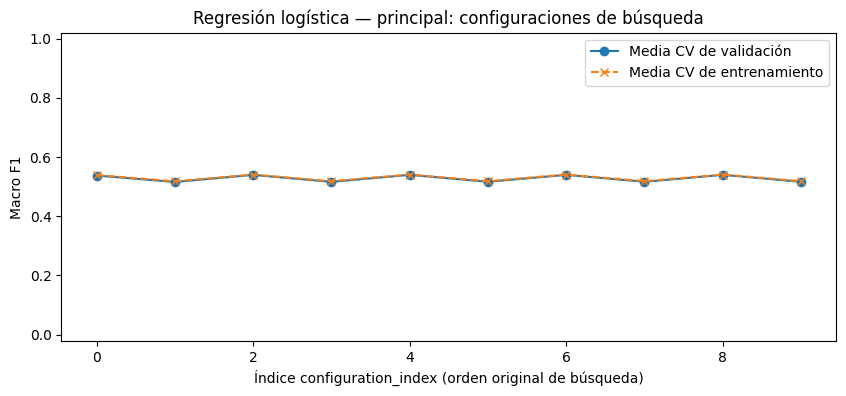

La configuración de índice **8** obtiene la mejor media CV. Las curvas muestran ajuste y validación dentro de entrenamiento; el eje no es una escala de complejidad.

### Diagnóstico en entrenamiento y comparación en validación fija

,partición,Macro F1,Accuracy
0,train,0.540808,0.539600
1,validation,0.534845,0.533733


,f1,precision,precision_undefined,recall,support
Low,0.509787,0.540109,False,0.482688,2455
Medium,0.539745,0.485988,False,0.606873,3172
High,0.555003,0.663941,False,0.476775,1873


Macro F1 = **0.534845**, Accuracy = **0.533733**. High: Precision **0.663941** y Recall **0.476775**. El soporte representa registros de cada etiqueta.

Brecha Macro F1 entrenamiento−validación = **0.005963**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

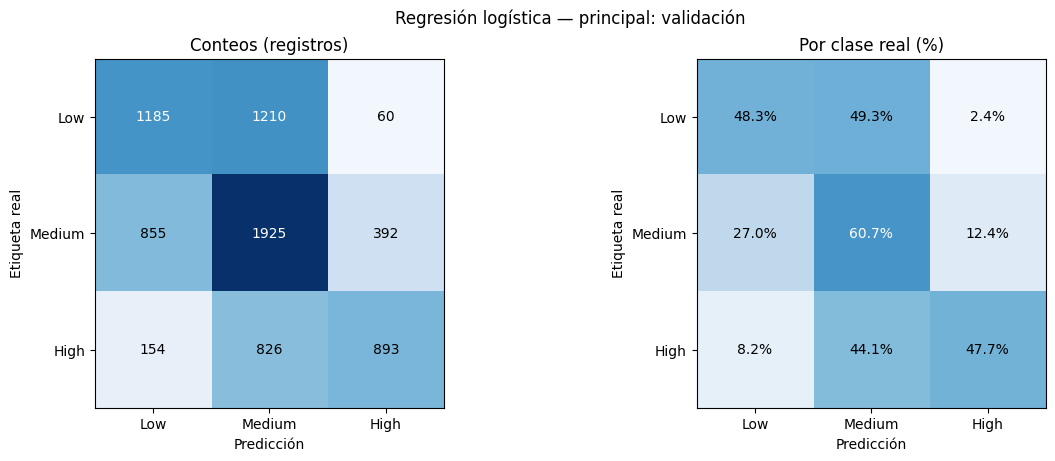

High→Low: **154**; High→Medium: **826**. Low→High: **60**; Medium→High: **392**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,51,predict and predict_proba; full pipeline,16.71955,0.202478,2026-10-09T19:41:38.012041+00:00,0.075442,0.031001


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

,class,feature,coefficient
0,High,numericas__Pre_Semester_GPA,-0.116811
1,High,numericas__Weekly_GenAI_Hours,0.781715
2,High,numericas__Tool_Diversity,0.001190
3,High,numericas__Traditional_Study_Hours,-0.105961
4,High,numericas__Perceived_AI_Dependency,0.183381
...,...,...,...
85,Medium,categoricas__Prompt_Engineering_Skill_Intermed...,0.059852
86,Medium,categoricas__Institutional_Policy_Actively_Enc...,0.100883
87,Medium,categoricas__Institutional_Policy_Allowed_With...,0.120347
88,Medium,categoricas__Institutional_Policy_Strict_Ban,-0.017543


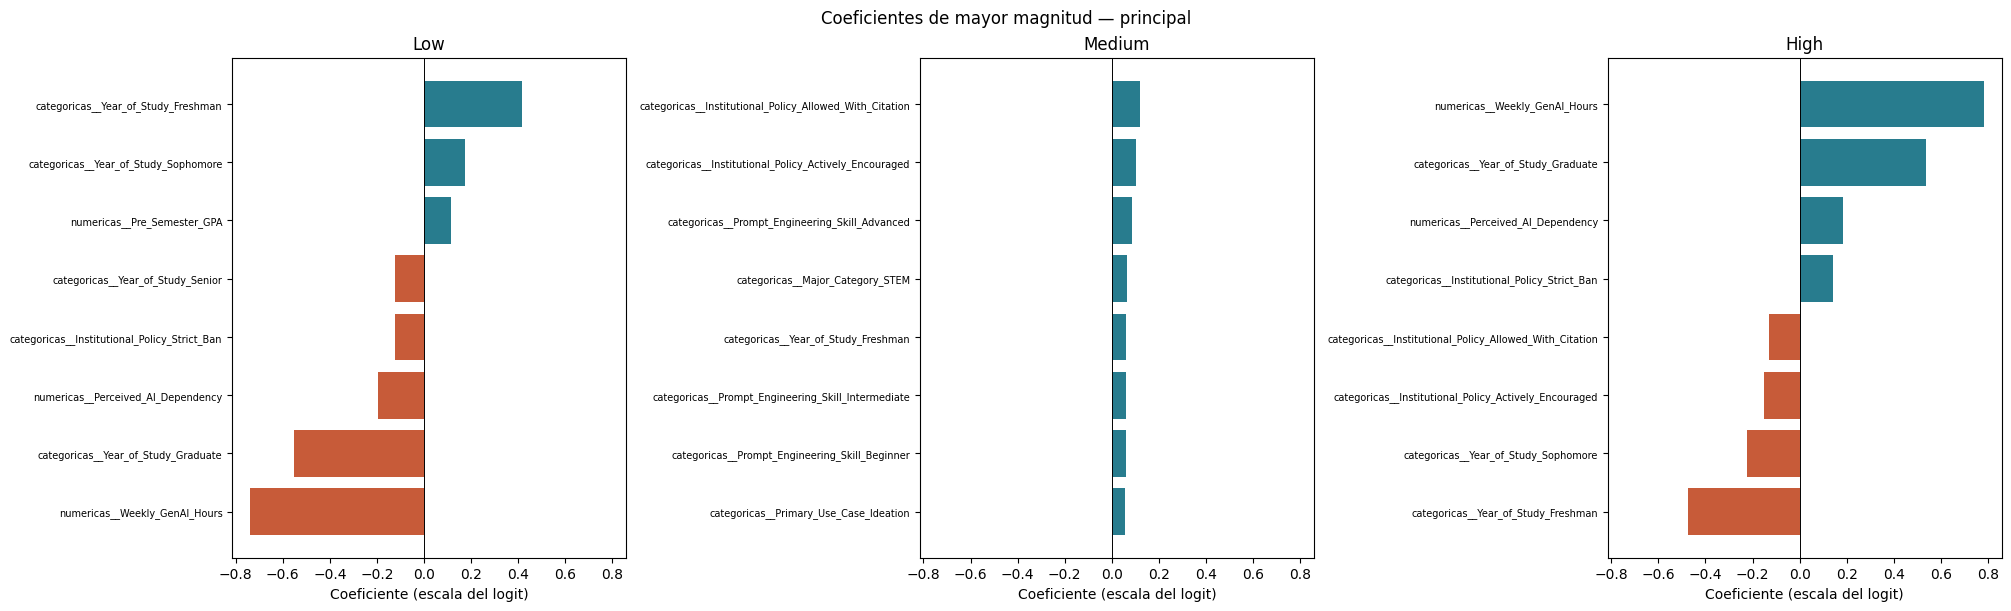

Convergencia: **True**, iteraciones **[22]** de máximo 5000. Las numéricas están estandarizadas dentro del entrenamiento correspondiente. L2 reduce magnitudes; con todas las categorías one-hot no hay una categoría de referencia eliminada. Los coeficientes forman una decisión conjunta multinomial y no prueban efectos causales ni una comparación inequívoca aislada.

### Conclusión del experimento
Macro F1 de validación **0.534845**; Recall de High **0.476775**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

{'best_params': {'clasificador__C': 100, 'clasificador__class_weight': None},
 'cv': {'configurations': 10,
  'fits': 51,
  'fold_scores': [0.5414943508249203,
   0.5409479362468371,
   0.5360530620837118,
   0.5439665669819598,
   0.5354140696482531],
  'macro_f1_mean': 0.5395751971571364,
  'macro_f1_std': 0.003303698229801341},
 'estimator_classes': ['High', 'Low', 'Medium'],
 'experiment_id': '3db94eb69df3c875',
 'interpretation': {'coefficients': 90,
  'converged': True,
  'iterations': [22],
  'max_iter': 5000,
  'transformed_features': 30},
 'model': 'logistica',
 'overfit_gap': 0.005962709847607273,
 'predictors': ['Major_Category',
  'Year_of_Study',
  'Pre_Semester_GPA',
  'Weekly_GenAI_Hours',
  'Primary_Use_Case',
  'Prompt_Engineering_Skill',
  'Tool_Diversity',
  'Paid_Subscription',
  'Traditional_Study_Hours',
  'Perceived_AI_Dependency',
  'Institutional_Policy',
  'Anxiety_Level_During_Exams',
  'Post_Semester_GPA',
  'Skill_Retention_Score'],
 'scenario': 'principal'

In [3]:
resultado = core.entrenar("logistica", directory=directory)
presentar_modelo("logistica", directory=directory)

## Referencia y cierre

[API scikit-learn 1.7.2](https://scikit-learn.org/1.7/modules/generated/sklearn.linear_model.LogisticRegression.html). La comparación definitiva se realiza en el notebook 05 y la prueba en el 06. Una métrica alta describe concordancia con etiquetas disponibles; no descubre su fórmula original ni acredita un resultado de negocio.